In [1]:
# Install required libraries
!pip install torch torchvision gradio scikit-learn matplotlib -q
print("Done!")

Done!


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import gradio as gr

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128


In [3]:
# Define transforms - resize, normalize images
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),   # Data augmentation
    transforms.RandomCrop(32, padding=4), # Data augmentation
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

# Load CIFAR-10 dataset (downloads automatically)
print("Downloading CIFAR-10 dataset...")
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True,
    download=True, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False,
    download=True, transform=transform_test
)

# Create data loaders
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True, num_workers=2
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=128, shuffle=False, num_workers=2
)

# Class names
classes = ['airplane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

print(f"\nTraining samples: {len(trainset)}")
print(f"Test samples: {len(testset)}")
print(f"Classes: {classes}")

100%|██████████| 170M/170M [00:07<00:00, 23.5MB/s]



Training samples: 50000
Test samples: 10000
Classes: ['airplane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


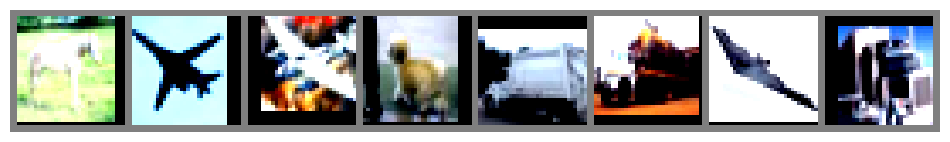

Labels: horse | airplane | airplane | dog | truck | truck | airplane | truck


In [4]:
# Show sample images from dataset
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.figure(figsize=(12, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Get random batch
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show 8 images
imshow(torchvision.utils.make_grid(images[:8]))
print("Labels:", ' | '.join([classes[labels[j]] for j in range(8)]))

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.25)

        # Block 2
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.25)

        # Block 3
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5   = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout(0.25)

        # Fully connected layers
        self.fc1   = nn.Linear(128 * 4 * 4, 512)
        self.bn7   = nn.BatchNorm1d(512)
        self.drop4 = nn.Dropout(0.5)
        self.fc2   = nn.Linear(512, 10)

        self.relu  = nn.ReLU()

    def forward(self, x):
        # Block 1
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.drop1(x)

        # Block 2
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.drop2(x)

        # Block 3
        x = self.relu(self.bn5(self.conv5(x)))
        x = self.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)
        x = self.drop3(x)

        # Flatten + FC layers
        x = x.view(x.size(0), -1)
        x = self.relu(self.bn7(self.fc1(x)))
        x = self.drop4(x)
        x = self.fc2(x)
        return x

# Initialize model
model = CNN().to(device)
print("Model created successfully!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model created successfully!
Total parameters: 1,343,146


In [7]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler - verbose removed (not supported in newer PyTorch)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5,
    patience=3
)

print("Optimizer and scheduler ready!")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")

Optimizer and scheduler ready!
Learning rate: 0.001


In [8]:
# Training loop
num_epochs = 20
best_accuracy = 0.0
train_losses = []
test_accuracies = []

print("Starting training...")
print("="*55)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Calculate test accuracy after each epoch
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    avg_loss = running_loss / len(trainloader)

    train_losses.append(avg_loss)
    test_accuracies.append(accuracy)

    # Save best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), 'best_model.pth')

    scheduler.step(accuracy)

    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | "
          f"Loss: {avg_loss:.4f} | "
          f"Accuracy: {accuracy:.2f}% | "
          f"Best: {best_accuracy:.2f}%")

print("="*55)
print(f"\nTraining complete! Best accuracy: {best_accuracy:.2f}%")

Starting training...
Epoch [ 1/20] | Loss: 1.4599 | Accuracy: 57.74% | Best: 57.74%
Epoch [ 2/20] | Loss: 1.0587 | Accuracy: 68.30% | Best: 68.30%
Epoch [ 3/20] | Loss: 0.9079 | Accuracy: 71.30% | Best: 71.30%
Epoch [ 4/20] | Loss: 0.8205 | Accuracy: 75.13% | Best: 75.13%
Epoch [ 5/20] | Loss: 0.7525 | Accuracy: 76.73% | Best: 76.73%
Epoch [ 6/20] | Loss: 0.7116 | Accuracy: 76.45% | Best: 76.73%
Epoch [ 7/20] | Loss: 0.6705 | Accuracy: 79.36% | Best: 79.36%
Epoch [ 8/20] | Loss: 0.6380 | Accuracy: 81.90% | Best: 81.90%
Epoch [ 9/20] | Loss: 0.6141 | Accuracy: 79.33% | Best: 81.90%
Epoch [10/20] | Loss: 0.5916 | Accuracy: 83.23% | Best: 83.23%
Epoch [11/20] | Loss: 0.5723 | Accuracy: 82.52% | Best: 83.23%
Epoch [12/20] | Loss: 0.5604 | Accuracy: 83.27% | Best: 83.27%
Epoch [13/20] | Loss: 0.5456 | Accuracy: 83.68% | Best: 83.68%
Epoch [14/20] | Loss: 0.5269 | Accuracy: 83.56% | Best: 83.68%
Epoch [15/20] | Loss: 0.5150 | Accuracy: 84.44% | Best: 84.44%
Epoch [16/20] | Loss: 0.5041 | Acc

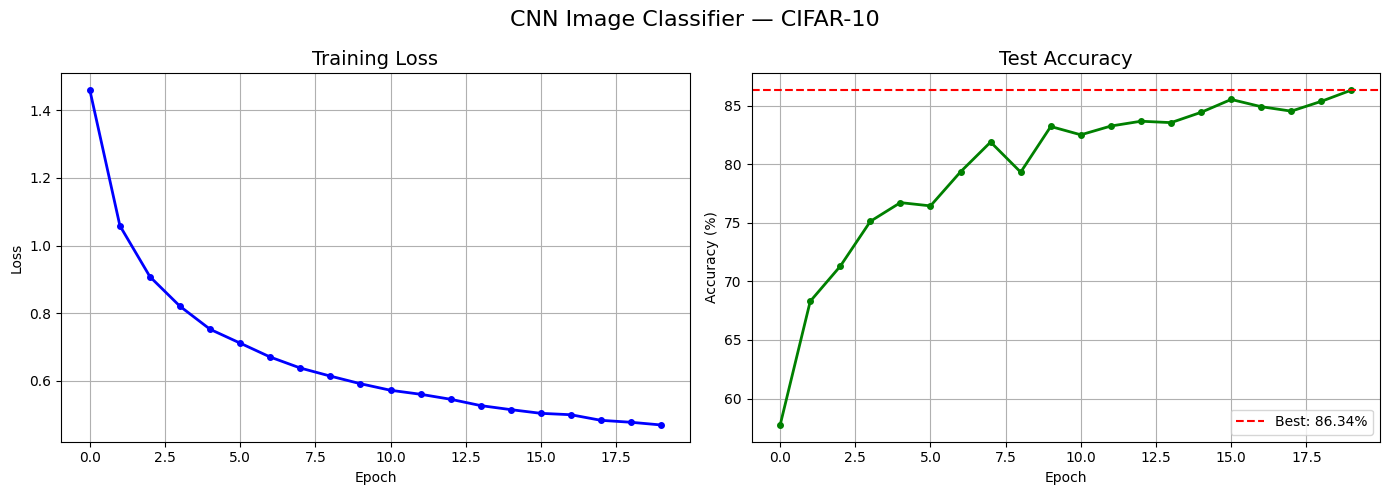

Best Test Accuracy: 86.34%


In [9]:
# Plot loss and accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, 'b-o', linewidth=2, markersize=4)
ax1.set_title('Training Loss', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(test_accuracies, 'g-o', linewidth=2, markersize=4)
ax2.axhline(y=best_accuracy, color='r',
            linestyle='--', label=f'Best: {best_accuracy:.2f}%')
ax2.set_title('Test Accuracy', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('CNN Image Classifier — CIFAR-10', fontsize=16)
plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best Test Accuracy: {best_accuracy:.2f}%")

In [10]:
# Load best model and evaluate
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("="*55)
print("CLASSIFICATION REPORT")
print("="*55)
print(classification_report(
    all_labels, all_preds,
    target_names=classes
))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    airplane       0.85      0.91      0.88      1000
         car       0.93      0.93      0.93      1000
        bird       0.88      0.74      0.80      1000
         cat       0.77      0.72      0.75      1000
        deer       0.85      0.87      0.86      1000
         dog       0.74      0.83      0.78      1000
        frog       0.90      0.89      0.90      1000
       horse       0.88      0.91      0.89      1000
        ship       0.95      0.90      0.92      1000
       truck       0.90      0.92      0.91      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [11]:
import gradio as gr
from PIL import Image
import torchvision.transforms as transforms
import torch

# Classes
classes = ['airplane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Class emojis for fun display
emojis = {
    'airplane': '✈️', 'car': '🚗', 'bird': '🐦',
    'cat': '🐱', 'deer': '🦌', 'dog': '🐶',
    'frog': '🐸', 'horse': '🐴', 'ship': '🚢', 'truck': '🚛'
}

# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
model.to(device)

# Transform for input image
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

def predict_image(image):
    if image is None:
        return "Please upload an image!"

    # Preprocess
    img = Image.fromarray(image).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0]

    # Get top 3 predictions
    top3_probs, top3_idx = torch.topk(probs, 3)

    predicted_class = classes[top3_idx[0].item()]
    confidence = top3_probs[0].item() * 100

    result = f"Prediction: {emojis[predicted_class]} {predicted_class.upper()}\n"
    result += f"Confidence: {confidence:.1f}%\n\n"
    result += "Top 3 predictions:\n"
    for i in range(3):
        cls = classes[top3_idx[i].item()]
        prob = top3_probs[i].item() * 100
        result += f"  {emojis[cls]} {cls}: {prob:.1f}%\n"

    return result

# Launch Gradio
demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(label="Upload an image"),
    outputs=gr.Textbox(label="Prediction Result", lines=8),
    title="🖼️ CNN Image Classifier — CIFAR-10",
    description="Upload any image and the CNN will classify it into one of 10 categories: airplane, car, bird, cat, deer, dog, frog, horse, ship, or truck.\n\nBuilt using PyTorch CNN with 86.34% accuracy on CIFAR-10 dataset.",
    examples=[],
    theme="soft"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://92984af8deb2b60b06.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
